In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv("SmartPhones_Sales.csv")
data

,Brands,Models,Colors,Memory,Storage,Camera,Rating,Selling Price,Original Price,Mobile,Discount,discount percentage
0,SAMSUNG,GALAXY M31S,Mirage Black,8 GB,128 GB,Yes,4.3,19330,20999,SAMSUNG GALAXY M31S,1669,7.947998
1,Nokia,3.2,Steel,2 GB,16 GB,Yes,3.8,10199,10199,Nokia 3.2,0,0.000000
2,realme,C2,Diamond Black,2 GB,NaN,Yes,4.4,6999,7999,realme C2,1000,12.501563
3,Infinix,Note 5,Ice Blue,4 GB,64 GB,Yes,4.2,12999,12999,Infinix Note 5,0,0.000000
4,Apple,iPhone 11,Black,4GB,64 GB,Yes,4.6,49900,49900,Apple iPhone 11,0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
3109,POCO,M4 Pro 5G,Cool Blue,6 GB,128 GB,Yes,4.4,16999,19999,POCO M4 Pro 5G,3000,15.000750
3110,Nokia,225,Black,NaN,Expandable Upto 32 GB,Yes,3.6,3499,3499,Nokia 225,0,0.000000
3111,Apple,iPhone SE,White,2 GB,128 GB,Yes,4.5,44900,44900,Apple iPhone SE,0,0.000000
3112,Apple,iPhone 13 Pro,Gold,6 GB,128 GB,Yes,NaN,119900,119900,Apple iPhone 13 Pro,0,0.000000


In [3]:
data.head(5)

,Brands,Models,Colors,Memory,Storage,Camera,Rating,Selling Price,Original Price,Mobile,Discount,discount percentage
0,SAMSUNG,GALAXY M31S,Mirage Black,8 GB,128 GB,Yes,4.3,19330,20999,SAMSUNG GALAXY M31S,1669,7.947998
1,Nokia,3.2,Steel,2 GB,16 GB,Yes,3.8,10199,10199,Nokia 3.2,0,0.000000
2,realme,C2,Diamond Black,2 GB,NaN,Yes,4.4,6999,7999,realme C2,1000,12.501563
3,Infinix,Note 5,Ice Blue,4 GB,64 GB,Yes,4.2,12999,12999,Infinix Note 5,0,0.000000
4,Apple,iPhone 11,Black,4GB,64 GB,Yes,4.6,49900,49900,Apple iPhone 11,0,0.000000


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3114 entries, 0 to 3113
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Brands               3114 non-null   object 
 1   Models               3114 non-null   object 
 2   Colors               3114 non-null   object 
 3   Memory               3071 non-null   object 
 4   Storage              3075 non-null   object 
 5   Camera               3114 non-null   object 
 6   Rating               2970 non-null   float64
 7   Selling Price        3114 non-null   int64  
 8   Original Price       3114 non-null   int64  
 9   Mobile               3114 non-null   object 
 10  Discount             3114 non-null   int64  
 11  discount percentage  3114 non-null   float64
dtypes: float64(2), int64(3), object(7)
memory usage: 292.1+ KB


In [5]:
data.describe()

,Rating,Selling Price,Original Price,Discount,discount percentage
count,2970.000000,3114.000000,3114.000000,3114.000000,3114.000000
mean,4.243098,26436.625562,28333.473025,1896.847463,6.086788
std,0.271991,30066.892622,31525.599889,5337.126176,11.106776
min,2.300000,1000.000000,1000.000000,-8000.000000,-160.320641
25%,4.100000,9990.000000,10030.250000,0.000000,0.000000
50%,4.300000,15000.000000,16889.500000,0.000000,0.000000
75%,4.400000,28999.000000,31500.000000,2000.000000,9.836388
max,5.000000,179900.000000,189999.000000,75000.000000,70.610305


In [6]:
data.isnull().sum()

Brands                   0
Models                   0
Colors                   0
Memory                  43
Storage                 39
Camera                   0
Rating                 144
Selling Price            0
Original Price           0
Mobile                   0
Discount                 0
discount percentage      0
dtype: int64

In [8]:
data.drop_duplicates(inplace=True)

In [9]:
data.fillna(0,inplace=True)

In [10]:
data.isnull().sum()

Brands                 0
Models                 0
Colors                 0
Memory                 0
Storage                0
Camera                 0
Rating                 0
Selling Price          0
Original Price         0
Mobile                 0
Discount               0
discount percentage    0
dtype: int64

In [11]:
data['Discount'] = data['Discount'].replace('%', '', regex=True).astype(float)

In [12]:
data.head(5)

,Brands,Models,Colors,Memory,Storage,Camera,Rating,Selling Price,Original Price,Mobile,Discount,discount percentage
0,SAMSUNG,GALAXY M31S,Mirage Black,8 GB,128 GB,Yes,4.3,19330,20999,SAMSUNG GALAXY M31S,1669.0,7.947998
1,Nokia,3.2,Steel,2 GB,16 GB,Yes,3.8,10199,10199,Nokia 3.2,0.0,0.000000
2,realme,C2,Diamond Black,2 GB,0,Yes,4.4,6999,7999,realme C2,1000.0,12.501563
3,Infinix,Note 5,Ice Blue,4 GB,64 GB,Yes,4.2,12999,12999,Infinix Note 5,0.0,0.000000
4,Apple,iPhone 11,Black,4GB,64 GB,Yes,4.6,49900,49900,Apple iPhone 11,0.0,0.000000


In [14]:
data['final_price'] = data['Original Price'] - (data['Original Price'] * data['Discount'] / 100)

In [17]:
data['value_score'] = data['Rating'] / data['final_price']

In [18]:
top_brands = data.groupby('Brands')['Rating'].mean().sort_values(ascending=False)
print(top_brands.head(10))

Brands
Google Pixel    4.506897
IQOO            4.400000
POCO            4.328378
Infinix         4.276000
Xiaomi          4.174242
SAMSUNG         4.148722
realme          4.146894
OPPO            4.146693
vivo            4.100000
Motorola        4.062500
Name: Rating, dtype: float64


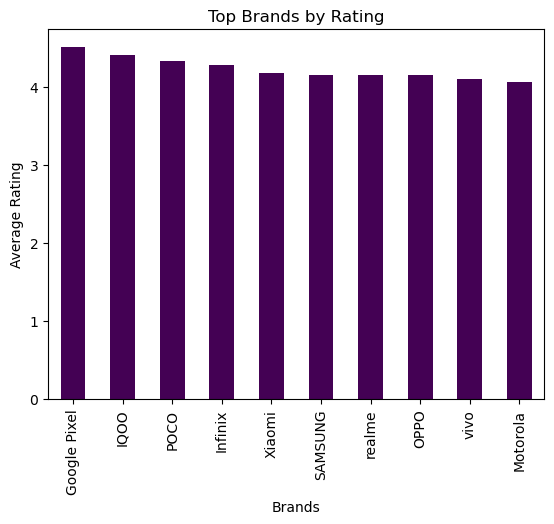

In [35]:
top_brands.head(10).plot(kind='bar', colormap='viridis')
plt.title("Top Brands by Rating")
plt.ylabel("Average Rating")
plt.show()

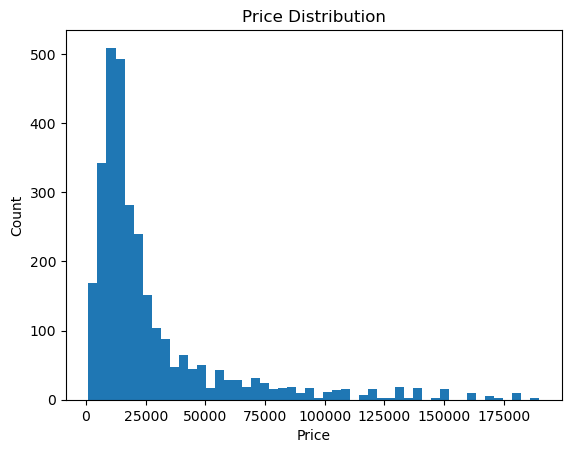

In [24]:
plt.hist(data['Original Price'], bins=50)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

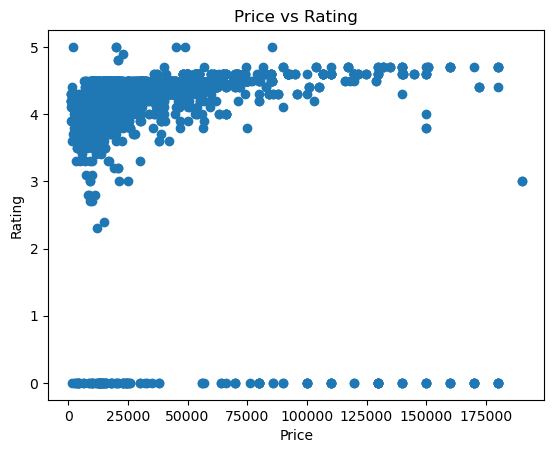

In [37]:
plt.scatter(data['Original Price'], data['Rating'])
plt.title("Price vs Rating")
plt.xlabel("Price")
plt.ylabel("Rating")
plt.show()

In [29]:
best_value = data.sort_values(by='value_score', ascending=False)

best_value[['Brands','Model','Original Price','Rating','value_score']].head(10)

,Brands,Models,Original Price,Rating,value_score
1067,SAMSUNG,Galaxy M32,15499,4.2,inf
1621,OPPO,A15S,12989,4.3,inf
1745,vivo,Y1S,13990,4.3,inf
1789,SAMSUNG,Galaxy A22 5G,23696,4.2,inf
1525,vivo,Y1S,13990,4.4,inf
1095,SAMSUNG,Galaxy M30,15990,4.3,inf
1133,Nokia,110 TA-1302 DS,1762,4.1,0.012927
599,Xiaomi,Mi 10i,24988,4.3,0.008604
1498,Nokia,150 DS 2020,2510,4.1,0.005445
2769,Xiaomi,Redmi 8A Dual,9290,4.5,0.005382


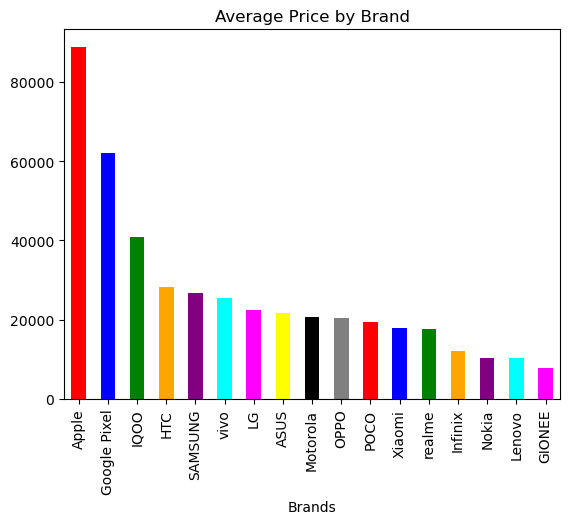

In [38]:
brand_price = data.groupby('Brands')['Original Price'].mean().sort_values(ascending=False)
brand_price.plot(kind='bar', color=['red','blue','green','orange','purple','cyan','magenta','yellow','black','grey'])
plt.title("Average Price by Brand")
plt.show()

In [32]:
top_discount = data.sort_values(by='Discount', ascending=False)

top_discount[['Brands','Models','Discount']].head(10)

,Brands,Models,Discount
711,Motorola,Razr,75000.0
589,Motorola,Razr,75000.0
848,Motorola,Razr 5G,60000.0
306,ASUS,ROG,57500.0
507,LG,Wing,50001.0
2632,LG,Wing,50001.0
410,Apple,iPhone XS Max,45901.0
911,Apple,iPhone XS Max,45901.0
1428,Apple,iPhone XS Max,45901.0
1482,LG,G8X,42010.0


In [40]:
data.to_csv("cleaned_smartphone_data.csv", index=False)